In [ ]:
# Visualization Tutorial

"""
Three functions for three levels of detail:

  1. plot_gt_rois()          — "Where is this brain region?"
  2. plot_gt_connectivity_2d() — "How are these two regions connected?"
  3. plot_roi_connectivity_3d() — "Show me the full network in 3D."

All use the bundled GT_414ROIs_atlas.nii.gz (Glasser 360 + Tian 54).
ROI indices are 0-413. See roi_labels.csv for the full list.
"""

from gt_map import GlasserTianParcellator, plot_gt_rois, plot_roi_connectivity_3d, plot_gt_connectivity_2d
import numpy as np

parc = GlasserTianParcellator()

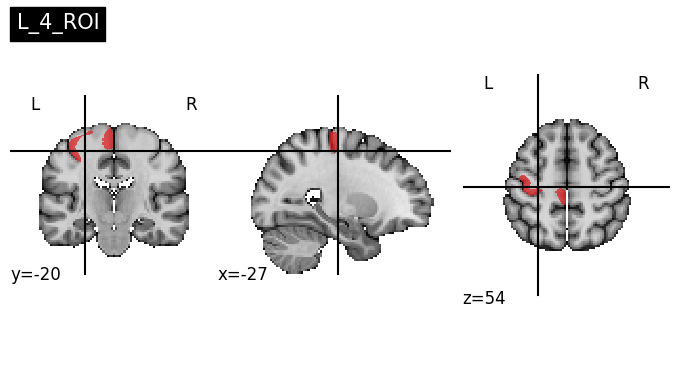

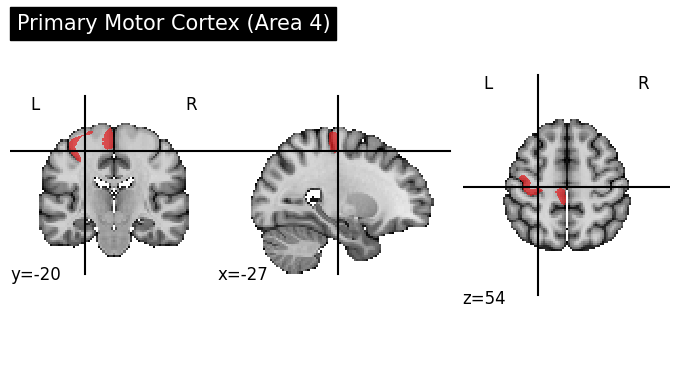

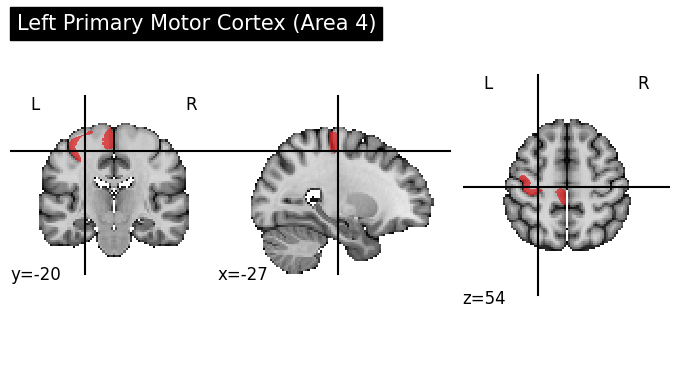

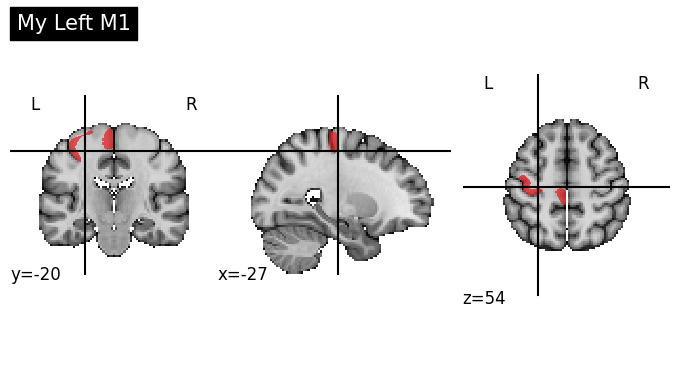

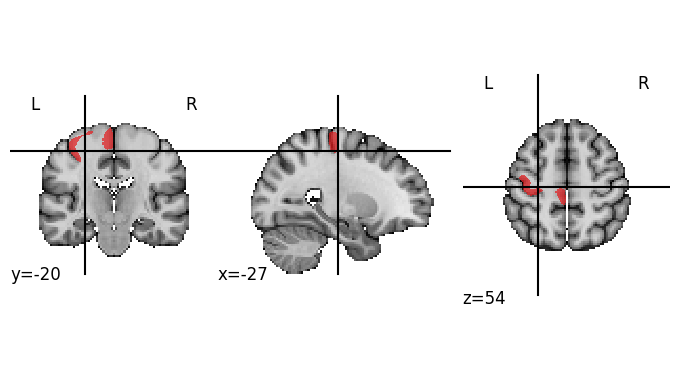

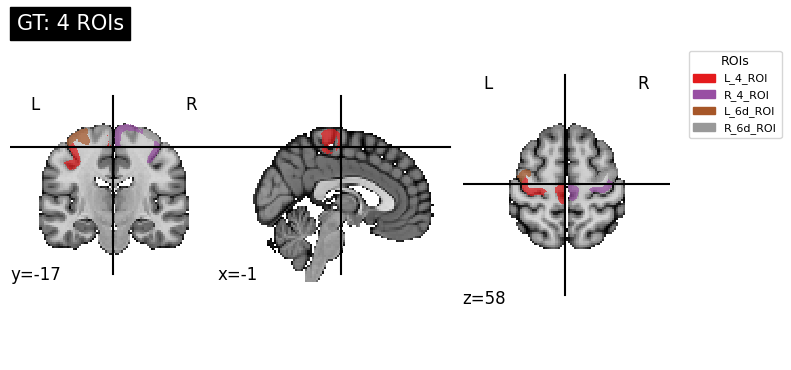

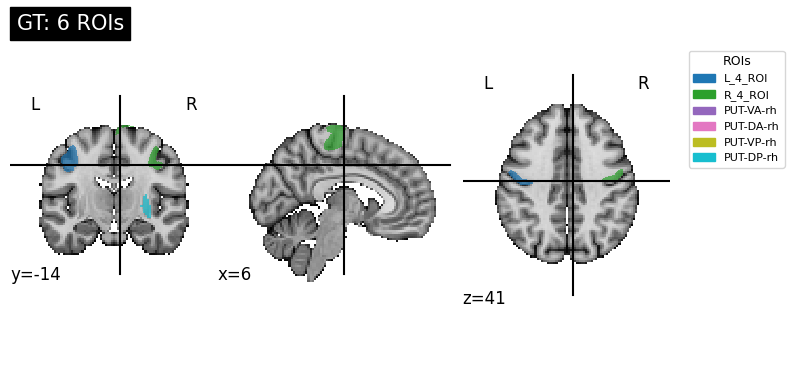

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. ANATOMICAL CHECK — plot_gt_rois()

"""
Quickly see where an ROI lives on the MNI brain.
Uses the unified GT_414ROIs_atlas.nii.gz — no separate Glasser/Tian handling.
"""

# Single ROI, short name (e.g., "L_4_ROI")
plot_gt_rois(7)

# Single ROI, full anatomical name
plot_gt_rois(7, label_type="region_full_name")
# → "Primary Motor Cortex (Area 4)"

# Single ROI, hemisphere + full name
plot_gt_rois(7, label_type="full")
# → "Left Primary Motor Cortex (Area 4)"

# Custom title
plot_gt_rois(7, title="My Left M1")

# No title
plot_gt_rois(7, title="")

# Multiple ROIs with color-matched legend
plot_gt_rois([7, 187, 53, 233], cmap='Set1', label_type="full")

# Change colormap
plot_gt_rois([7, 187, 372, 373, 374, 375], cmap='tab10')

# Save to file instead of displaying
plot_gt_rois([7, 187], label_type="full", save_to="motor_cortex.png")

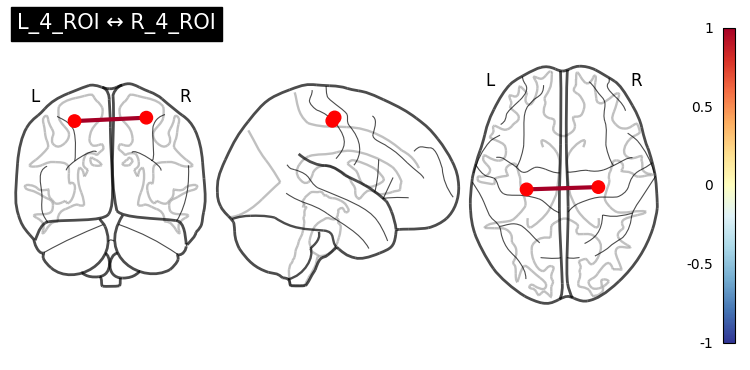

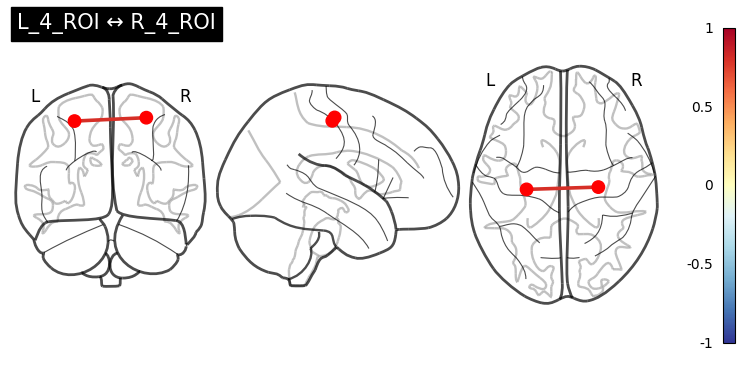

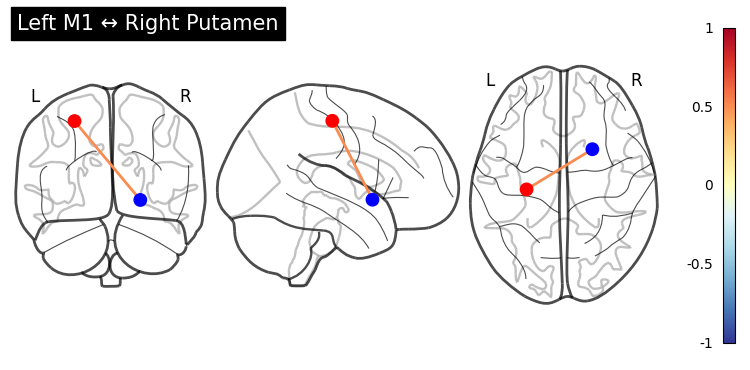

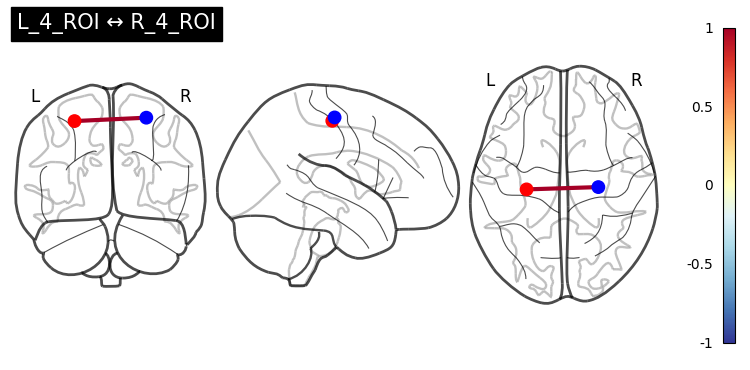

In [ ]:
# 2. SINGLE CONNECTION — plot_gt_connectivity_2d()

"""
Show a line between two ROIs on the MNI template.
Useful for highlighting a specific connection of interest.
"""

# Bare minimum — just the two indices
plot_gt_connectivity_2d(7, 187)

# With a custom weight (line thickness and color)
plot_gt_connectivity_2d(7, 187, weight=0.8)

# Custom title
plot_gt_connectivity_2d(7, 372, weight=0.5, title="Left M1 ↔ Right Putamen")

# Custom node colors
plot_gt_connectivity_2d(7, 187, node_colors=['#FF0000', '#0000FF'])

In [8]:
# 3D Connectivity Network 

from gt_map import GlasserTianParcellator, plot_roi_connectivity_3d
import numpy as np

parc = GlasserTianParcellator()

# Create your connectivity matrix (replace with real data)
matrix = np.random.rand(414, 414)
np.fill_diagonal(matrix, 0)
matrix = (matrix + matrix.T) / 2

fig = plot_roi_connectivity_3d(
    # ── Required ───────────────────────────────────────────
    indices=[7, 187, 53, 233, 372, 373, 374, 375],  # ROI indices 0-413
    matrix=matrix,                                    # 414×414 connectivity matrix
    parcellator=parc,                                 # provides atlas + labels

    # ── Edge filtering ─────────────────────────────────────
    top_n=10,                          # show only 10 strongest edges (None = all)

    # ── Colors ─────────────────────────────────────────────
    edge_cmap='Purples',               # edge color gradient
    node_cmap='Set1',                  # node color palette (qualitative)

    # ── Display toggles ────────────────────────────────────
    show_labels_on_map=True,           # ROI names floating above nodes
    show_legend=True,                  # legend panel on the right
    show_colorbar=False,               # edge weight colorbar (keep False)

    # ── Visual scaling ─────────────────────────────────────
    node_size_scale=0.5,               # 1.0 = default, <1 smaller, >1 larger
    edge_width_scale=0.8,              # 1.0 = default, <1 thinner, >1 thicker

    # ── Title & export ─────────────────────────────────────
    title="Motor Network Connectivity",
    save_path="motor_network.html",    # export interactive HTML (None = skip)
)

fig.show()